# Exploring Streaky Performances

## 10.1 Introduction



- This chapter explores streaky or hot/cold performances by baseball hitters, using Joe DiMaggio's  56 game hitting streak in 1941 as an example.
- Topics covered include game level hitting streaks, at bat level slump analysis using Retrosheet data, and measuring streakiness through launch speed variability.

## 10.2 The Great Streak

### 10.2.1 Finding game hitting streaks

- Load DiMaggio's 1941 game-by-game hitting log and verify his season batting average.
- Create a binary indicator for whether he recorded at least one hit in each game, then use run-length encoding to identify all consecutive hitting and hitless streaks.

In [15]:
import pandas as pd
import numpy as np

dimaggio = pd.read_csv('../data/dimaggio.1941.csv')
round(dimaggio['H'].sum() / dimaggio['AB'].sum(), 3)

np.float64(0.357)

In [16]:
dimaggio['had_hit'] = (dimaggio['H'] >= 1).astype(int)

dimaggio['streak_id'] = (dimaggio['had_hit'] != dimaggio['had_hit'].shift()).cumsum()
streaks = dimaggio.groupby(['streak_id', 'had_hit']).size().reset_index(name='length')

print("Hitting streaks:", streaks[streaks['had_hit'] == 1]['length'].tolist())
print("Hitless streaks:", streaks[streaks['had_hit'] == 0]['length'].tolist())

Hitting streaks: [8, 3, 2, 1, 3, 56, 16, 4, 2, 4, 7, 1, 5, 2]
Hitless streaks: [3, 1, 2, 3, 2, 1, 2, 2, 3, 3, 1, 1, 1]


- DiMaggio's 56 game hitting streak was immediately followed by a 16 game streak.
- His longest hitless stretch was just 3 consecutive games

### 10.2.2 Moving batting averages

- Compute a 10-game rolling batting average to reveal performance trends, plotted against DiMaggio's season average.

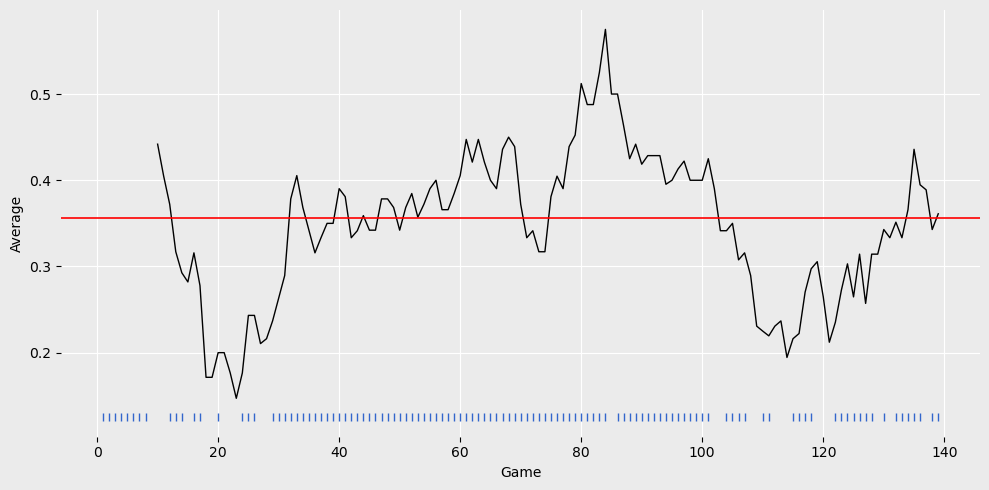

In [17]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

width = 10
dimaggio['game'] = range(1, len(dimaggio) + 1)
dimaggio['rolling_avg'] = (
    dimaggio['H'].rolling(width).sum() / 
    dimaggio['AB'].rolling(width).sum()
)

season_avg = dimaggio['H'].sum() / dimaggio['AB'].sum()
hit_games = dimaggio[dimaggio['had_hit'] == 1]['game']

fig, ax = plt.subplots(figsize=(10, 5), facecolor='#EBEBEB')
ax.set_facecolor('#EBEBEB')
ax.grid(color='white', linewidth=0.8)
ax.plot(dimaggio['game'], dimaggio['rolling_avg'], color='black', linewidth=1)
ax.axhline(season_avg, linestyle='solid', color='red', linewidth=1.2)
ax.plot(hit_games, [0.125] * len(hit_games), '|', color='#3366CC', markersize=6, markeredgewidth=1)
ax.set_xlabel('Game')
ax.set_ylabel('Average')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.1f}'))
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

- During the 56-game streak, DiMaggio's rolling average climbed well above .500 at its peak.
- A noticeable slump appears in the second half of the season, dipping well below his .357 season average around game 110.
- The rug marks at the bottom show games where he recorded a hit — nearly every game during the streak period.

## 10.3 Streaks in Individual At-Bats

- Shifts from game-level to individual at-bat analysis using Retrosheet play-by-play data, examining Ichiro Suzuki's 2016 hitting patterns.

### 10.3.1 Streaks of hits and outs

- Filter Retrosheet play-by-play data for Ichiro's at-bats and create a binary hit indicator, then find his longest hitting and hitless streaks.

In [18]:
fields = pd.read_csv('../data/fields.csv')
headers = fields['Header'].str.lower().tolist()
retro2016 = pd.read_csv('../data/all2016.csv', names=headers, low_memory=False)

ichiro = retro2016[(retro2016['bat_id'] == 'suzui001') & (retro2016['ab_fl'] == 'T')].copy()
ichiro['H'] = (ichiro['h_fl'] > 0).astype(int)
ichiro = ichiro.sort_values(['game_id', 'event_id']).reset_index(drop=True)

ichiro['streak_id'] = (ichiro['H'] != ichiro['H'].shift()).cumsum()
streaks_ichiro = ichiro.groupby(['streak_id', 'H']).size().reset_index(name='length')

print("Longest hit streak:", streaks_ichiro[streaks_ichiro['H'] == 1]['length'].max())
print("Longest hitless streak:", streaks_ichiro[streaks_ichiro['H'] == 0]['length'].max())

Longest hit streak: 5
Longest hitless streak: 14


### 10.3.2 Moving batting averages

- Apply a 30 at-bat rolling average to Ichiro's hit/out sequence to visualize hot and cold stretches across the season.

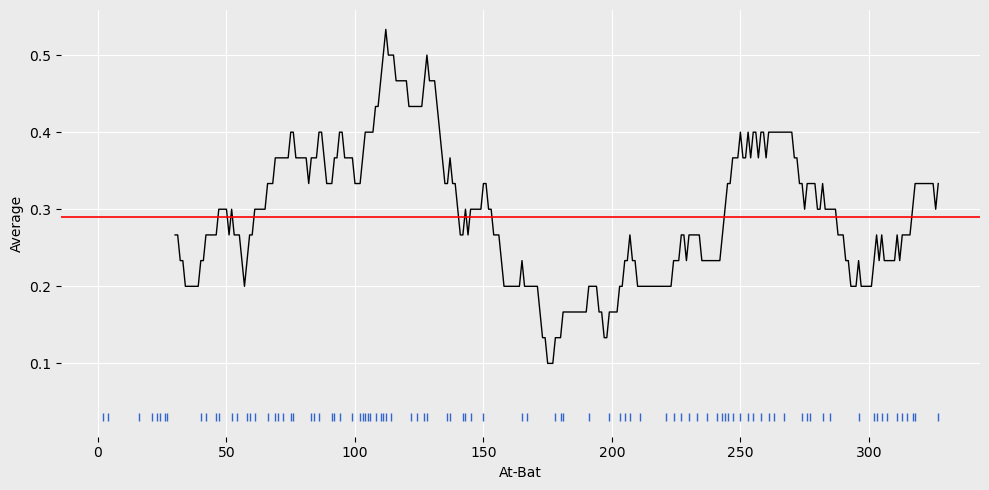

In [19]:
width = 30
ichiro['at_bat'] = range(1, len(ichiro) + 1)
ichiro['rolling_avg'] = ichiro['H'].rolling(width).mean()

season_avg = ichiro['H'].mean()
hit_abs = ichiro[ichiro['H'] == 1]['at_bat']

fig, ax = plt.subplots(figsize=(10, 5), facecolor='#EBEBEB')
ax.set_facecolor('#EBEBEB')
ax.grid(color='white', linewidth=0.8)
ax.plot(ichiro['at_bat'], ichiro['rolling_avg'], color='black', linewidth=1)
ax.axhline(season_avg, linestyle='solid', color='red', linewidth=1.2)
ax.plot(hit_abs, [0.03] * len(hit_abs), '|', color='#3366CC', markersize=6, markeredgewidth=1)
ax.set_xlabel('At-Bat')
ax.set_ylabel('Average')
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

- Ichiro's 30 at-bat average peaks above .500 during hot stretches and dips near .100 during cold ones

### 10.3.3 Finding hitting slumps for all players

- Find the longest hitless streak for every player with at least 400 at-bats in 2016, then rank by worst slump.

In [20]:
ab_counts = (retro2016[retro2016['ab_fl'] == 'T']
    .groupby('bat_id').size()
    .reset_index(name='ab_count')
)
qualifying = ab_counts[ab_counts['ab_count'] >= 400]['bat_id'].tolist()

at_bats = retro2016[(retro2016['bat_id'].isin(qualifying)) & (retro2016['ab_fl'] == 'T')].copy()
at_bats['H'] = (at_bats['h_fl'] > 0).astype(int)
at_bats = at_bats.sort_values(['bat_id', 'game_id', 'event_id']).reset_index(drop=True)

def longest_ofer(group):
    H = group['H']
    streak_id = (H != H.shift()).cumsum()
    streaks = group.groupby(streak_id)['H'].agg(['first', 'count'])
    hitless = streaks[streaks['first'] == 0]['count']
    return hitless.max() if len(hitless) > 0 else 0

slumps = (at_bats.groupby('bat_id')
    .apply(longest_ofer, include_groups=False)
    .reset_index(name='longest_slump')
)

people = pd.read_csv('../data/lahman/People.csv')
slumps = slumps.merge(people[['retroID', 'nameFirst', 'nameLast']], 
                      left_on='bat_id', right_on='retroID', how='left')
slumps['name'] = slumps['nameFirst'] + ' ' + slumps['nameLast']

slumps.nlargest(10, 'longest_slump')[['name', 'longest_slump']]

,name,longest_slump
68,Adrian Gonzalez,33
53,Danny Espinosa,31
43,Corey Dickerson,27
182,Ben Zobrist,27
0,Jose Abreu,26
63,Brett Gardner,26
139,Albert Pujols,26
96,Francisco Lindor,25
121,Eduardo Nunez,25
129,Joc Pederson,25


### 10.3.4 Were Ichiro Suzuki and Mike Trout unusually streaky?

- Use a **clumpiness statistic** — the sum of squared gaps between consecutive hits — to measure how bunched a player's hits are.
- A randomization test shuffles the hit/out sequence 1,000 times to build a null distribution, then compares the observed statistic to see if the player is genuinely streakier than chance.

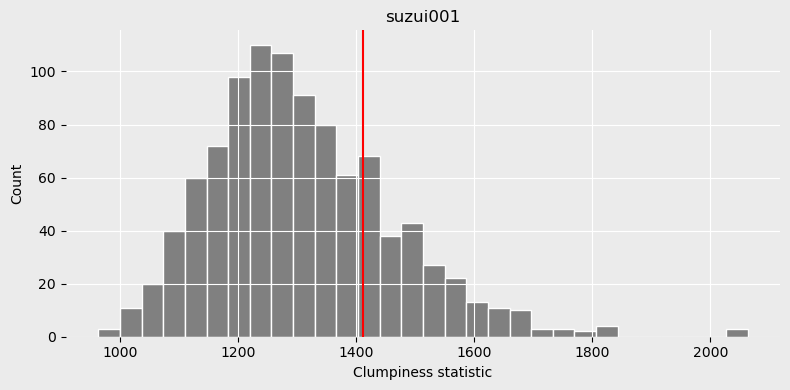

Observed S = 1411, percentile = 77.4th


In [21]:
def clumpiness(H):
    hit_positions = np.where(H == 1)[0]
    if len(hit_positions) < 2:
        return 0
    gaps = np.diff(hit_positions) - 1
    return int(np.sum(gaps ** 2))

def clump_test(player_id, n_sim=1000, seed=42):
    player = retro2016[(retro2016['bat_id'] == player_id) & (retro2016['ab_fl'] == 'T')].copy()
    player['H'] = (player['h_fl'] > 0).astype(int)
    player = player.sort_values(['game_id', 'event_id']).reset_index(drop=True)

    H = player['H'].values
    observed = clumpiness(H)

    rng = np.random.default_rng(seed)
    simulated = [clumpiness(rng.permutation(H)) for _ in range(n_sim)]

    fig, ax = plt.subplots(figsize=(8, 4), facecolor='#EBEBEB')
    ax.set_facecolor('#EBEBEB')
    ax.grid(color='white', linewidth=0.8)
    ax.hist(simulated, bins=30, color='gray', edgecolor='white')
    ax.axvline(observed, color='red', linewidth=1.5)
    ax.set_xlabel('Clumpiness statistic')
    ax.set_ylabel('Count')
    ax.set_title(player_id)
    for spine in ax.spines.values():
        spine.set_visible(False)
    plt.tight_layout()
    plt.show()

    pct = np.mean(np.array(simulated) < observed) * 100
    print(f"Observed S = {observed}, percentile = {pct:.1f}th")

clump_test('suzui001')

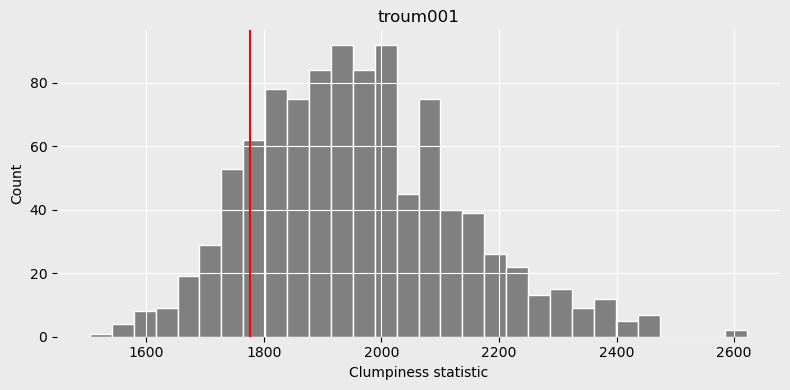

Observed S = 1776, percentile = 14.4th


In [22]:
clump_test('troum001')

## 10.4 Local Patterns of Statcast Launch Velocity

- Instead of hit/out sequences, this section measures streakiness using **Statcast launch velocity** — how hard a batter hits the ball.
- Fetch 2017 Statcast data, group each player's games into 5-game blocks, and compare the standard deviation of those block averages across all qualified hitters.

- Fetch full 2017 Statcast data using `pybaseball`, filter for batted balls (`type == "X"`), and aggregate launch speed by player and game date.

In [23]:
from pybaseball import statcast, playerid_reverse_lookup
import warnings
warnings.filterwarnings('ignore')

sc_2017 = statcast(start_dt='2017-04-02', end_dt='2017-10-01')
sc_ip2017 = sc_2017[sc_2017['type'] == 'X'].copy()

launch_speeds = (
    sc_ip2017
    .groupby(['batter', 'game_date'])
    .agg(bip=('launch_speed', 'count'), sum_LS=('launch_speed', 'sum'))
    .reset_index()
    .sort_values(['batter', 'game_date'])
)

# Look up batter names by MLBAM ID
batter_ids = launch_speeds['batter'].unique().tolist()
name_lookup = playerid_reverse_lookup(batter_ids, key_type='mlbam')
name_lookup['player_name'] = (
    name_lookup['name_first'].str.title() + ' ' + name_lookup['name_last'].str.title()
)
launch_speeds = launch_speeds.merge(
    name_lookup[['key_mlbam', 'player_name']],
    left_on='batter', right_on='key_mlbam',
    how='left'
)

print(f"Batted ball events: {len(sc_ip2017):,}")
print(f"Player-game rows: {len(launch_speeds):,}")

This is a large query, it may take a moment to complete


100%|██████████| 183/183 [00:35<00:00,  5.13it/s]


Batted ball events: 127,556
Player-game rows: 47,239


In [24]:
bip_totals = launch_speeds.groupby('player_name')['bip'].sum().reset_index()
ls_250 = launch_speeds[launch_speeds['player_name'].isin(
    bip_totals[bip_totals['bip'] >= 250]['player_name']
)]

print(f"Qualifying players (250+ BIP): {ls_250['player_name'].nunique()}")

Qualifying players (250+ BIP): 237


- `regroup()` collapses a player's game-by-game rows into consecutive 5-game blocks, merging any leftover games into the prior block.
- `summarize_streak_data()` returns the mean and SD of block-level average launch speeds.
- `get_streak_data()` returns the per-period averages for individual player plots.

In [25]:
import math

def regroup(data, group_size=5):
    df = data.copy().reset_index(drop=True)
    df['id'] = df.index
    df['group_id'] = df['id'] // group_size

    if len(df) % group_size != 0:
        max_group = df['group_id'].max()
        df.loc[df['group_id'] == max_group, 'group_id'] = max_group - 1

    return (
        df.groupby('group_id')
        .agg(G=('bip', 'count'), bip=('bip', 'sum'), sum_LS=('sum_LS', 'sum'))
        .reset_index(drop=True)
    )


def summarize_streak_data(data, name, group_size=5):
    player_data = data[data['player_name'] == name].sort_values('game_date')
    grouped = regroup(player_data, group_size)
    grouped['avg_LS'] = grouped['sum_LS'] / grouped['bip']
    return pd.DataFrame({
        'balls_in_play': [grouped['bip'].sum()],
        'Mean': [grouped['avg_LS'].mean()],
        'SD': [grouped['avg_LS'].std()],
    })


def get_streak_data(data, name, group_size=5):
    player_data = data[data['player_name'] == name].sort_values('game_date')
    grouped = regroup(player_data, group_size)
    grouped['launch_speed_avg'] = grouped['sum_LS'] / grouped['bip']
    grouped['Period'] = range(1, len(grouped) + 1)
    return grouped

- Apply `summarize_streak_data()` to all 250+ BIP players and plot mean launch speed vs. its standard deviation across 5 game periods.

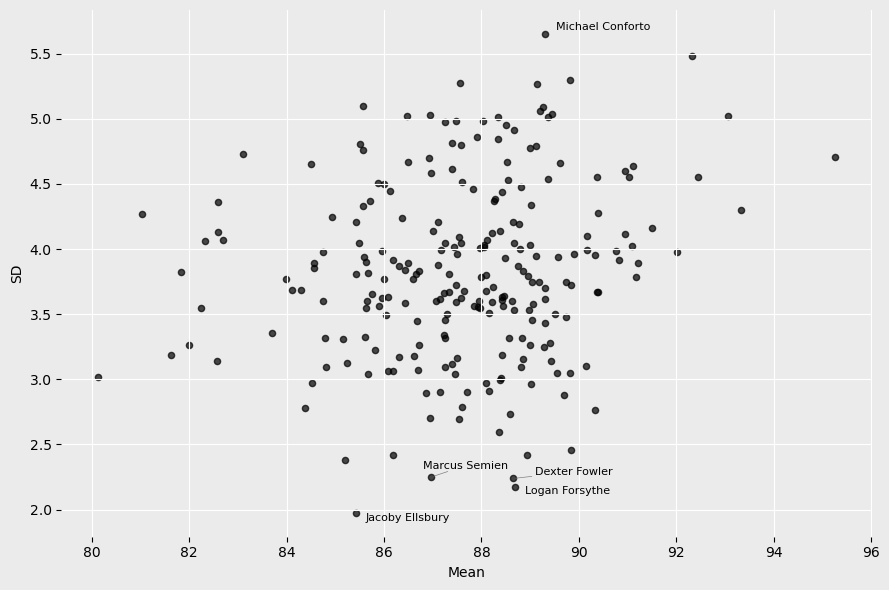

In [26]:
from adjustText import adjust_text

player_list = ls_250['player_name'].unique().tolist()

results = pd.concat(
    [summarize_streak_data(ls_250, name).assign(Player=name) for name in player_list],
    ignore_index=True
)

outliers = results[(results['SD'] > 5.63) | (results['SD'] < 2.3)]

fig, ax = plt.subplots(figsize=(9, 6), facecolor='#EBEBEB')
ax.set_facecolor('#EBEBEB')
ax.grid(color='white', linewidth=0.8)
ax.scatter(results['Mean'], results['SD'], color='black', s=20, alpha=0.7)

texts = []
for _, row in outliers.iterrows():
    texts.append(ax.text(row['Mean'], row['SD'], row['Player'], fontsize=8))

adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

ax.set_xlabel('Mean')
ax.set_ylabel('SD')
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

- Compare period-by-period launch speed averages for the streakiest hitter (highest SD) and most consistent hitter (lowest SD) side by side.

In [27]:
streakiest = 'Michael Conforto'
most_consistent = 'Dexter Fowler'

conforto_sd = results.loc[results['Player'] == streakiest, 'SD'].values[0]
fowler_sd = results.loc[results['Player'] == most_consistent, 'SD'].values[0]
print(f"Streakiest: {streakiest} (SD = {conforto_sd:.2f})")
print(f"Most consistent: {most_consistent} (SD = {fowler_sd:.2f})")

Streakiest: Michael Conforto (SD = 5.65)
Most consistent: Dexter Fowler (SD = 2.24)


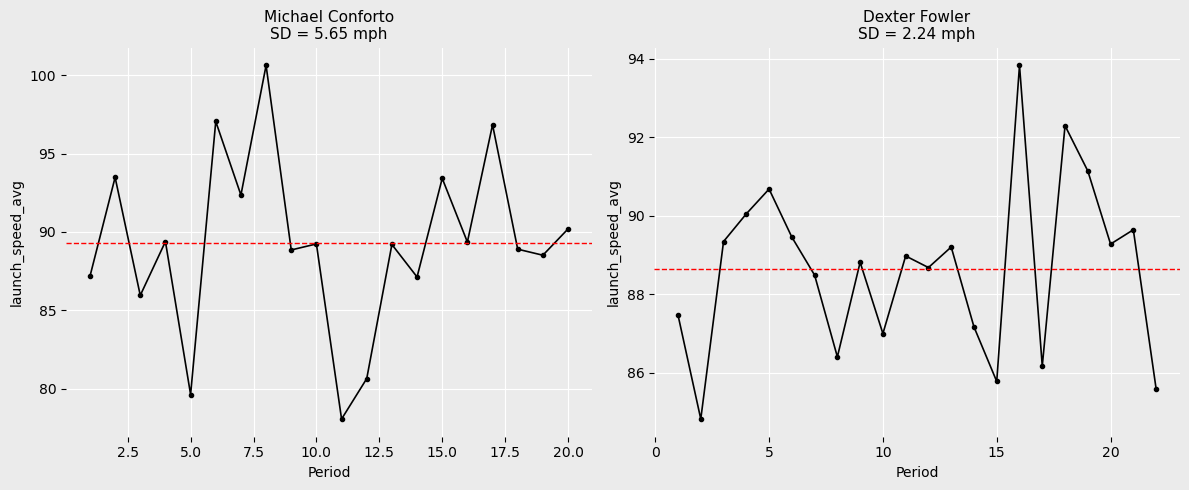

In [28]:
players_to_plot = [streakiest, most_consistent]
streak_data = {name: get_streak_data(ls_250, name) for name in players_to_plot}

fig, axes = plt.subplots(1, 2, figsize=(12, 5), facecolor='#EBEBEB', sharey=False)

for ax, name in zip(axes, players_to_plot):
    df = streak_data[name]
    sd_val = results.loc[results['Player'] == name, 'SD'].values[0]
    ax.set_facecolor('#EBEBEB')
    ax.grid(color='white', linewidth=0.8)
    ax.plot(df['Period'], df['launch_speed_avg'], color='black', linewidth=1.2, marker='o', markersize=3)
    ax.axhline(df['launch_speed_avg'].mean(), color='red', linestyle='--', linewidth=1)
    ax.set_title(f"{name}\nSD = {sd_val:.2f} mph", fontsize=11)
    ax.set_xlabel('Period')
    ax.set_ylabel('launch_speed_avg')
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.tight_layout()
plt.show()

- Conforto's 5-game averages swing from 80 to 100 mph — clear hot and cold stretches throughout the season.
- Fowler's averages stay tightly clustered between 85–90 mph all year.
- SD of 5-game block averages is a simple, effective measure of launch velocity streakiness.